## SETUP for run

In [1]:
import sys
import subprocess

# Install required packages for this notebook
required_packages = ["torch", "torchvision", "torchaudio", "soundfile", "matplotlib"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")

import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class SpeechDigitDataset(Dataset):
    def __init__(self, data_dir, is_train=True, audio_aug=False, img_aug=False):
        self.data_dir = data_dir
        self.filepaths = []
        self.labels = []
        self.audio_aug = audio_aug
        self.img_aug = img_aug

        subset_dir = 'Train' if is_train else 'Test'
        full_subset_path = os.path.join(data_dir, subset_dir)
        if not os.path.exists(full_subset_path):
            print(f"Warning: Directory not found: {full_subset_path}")
        else:
            for file in os.listdir(full_subset_path):
                if file.endswith('.wav'):
                    filepath = os.path.join(full_subset_path, file)
                    self.filepaths.append(filepath)
                    try:
                        label = int(file.split('_')[1].split('.')[0])
                        self.labels.append(label)
                    except (IndexError, ValueError):
                        pass

        self.spectrogramer = T.MelSpectrogram(sample_rate=16000, n_mels=64)
        self.resize = transforms.Resize((32, 32))
        # Reduced SpecAugment parameters to avoid over-augmentation
        self.freq_mask = T.FrequencyMasking(freq_mask_param=7)
        self.time_mask = T.TimeMasking(time_mask_param=7)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]
        waveform, sample_rate = torchaudio.load(path)

        if self.audio_aug:
            noise = torch.randn_like(waveform) * 0.002
            waveform = waveform + noise

        spec = self.spectrogramer(waveform)
        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = self.resize(spec)

        if self.img_aug:
            # Apply Spectrum Augmentation (SpecAugment) - reduced intensity
            spec = self.freq_mask(spec)
            spec = self.time_mask(spec)

        return spec, label

Using device: cuda


In [2]:
print('Installing ffmpeg...')
!apt-get -qq install ffmpeg
print('ffmpeg installed.')

Installing ffmpeg...
ffmpeg installed.


## **1: Setup and Environment**

In [3]:
import sys
import subprocess

# Install required packages for this notebook
required_packages = ["torch", "torchvision", "torchaudio", "matplotlib"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")


In [4]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Google Colab Drive mounting (commented out for local use)
# from google.colab import drive
# drive.mount('/content/drive')

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Google Colab Drive mounting (commented out for local use)
from google.colab import drive
drive.mount('/content/drive')

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [7]:
import sys
import subprocess

print("Python executable:", sys.executable)
print("Python version:", sys.version)

# Ensure required packages are installed in the current kernel environment
required_packages = ["torch", "torchvision", "torchaudio"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")


Python executable: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


# **Question 2 - Preparing ReducedMNIST**

**Objective**: Create a "ReducedMNIST" dataset with 1000 training examples and 200 testing examples per digit.

We will download the standard MNIST dataset and use PyTorch's Subset to randomly sample the exact number of examples required. We also apply a basic ToTensor() transform to convert the images to PyTorch tensors.


In [8]:
def get_reduced_mnist(train_samples_per_class=1000, test_samples_per_class=200):
    transform = transforms.Compose([transforms.ToTensor()])

    # Download full MNIST
    full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    full_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Helper function to get balanced subsets
    def create_subset(dataset, samples_per_class):
        indices = []
        targets = dataset.targets.numpy()
        for i in range(10): # 10 digits
            class_indices = np.where(targets == i)[0]
            np.random.shuffle(class_indices)
            indices.extend(class_indices[:samples_per_class])
        return Subset(dataset, indices)

    reduced_train = create_subset(full_train, train_samples_per_class)
    reduced_test = create_subset(full_test, test_samples_per_class)

    return reduced_train, reduced_test

train_set, test_set = get_reduced_mnist()
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print(f"Reduced Train size: {len(train_set)} | Reduced Test size: {len(test_set)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 439kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


Reduced Train size: 10000 | Reduced Test size: 2000


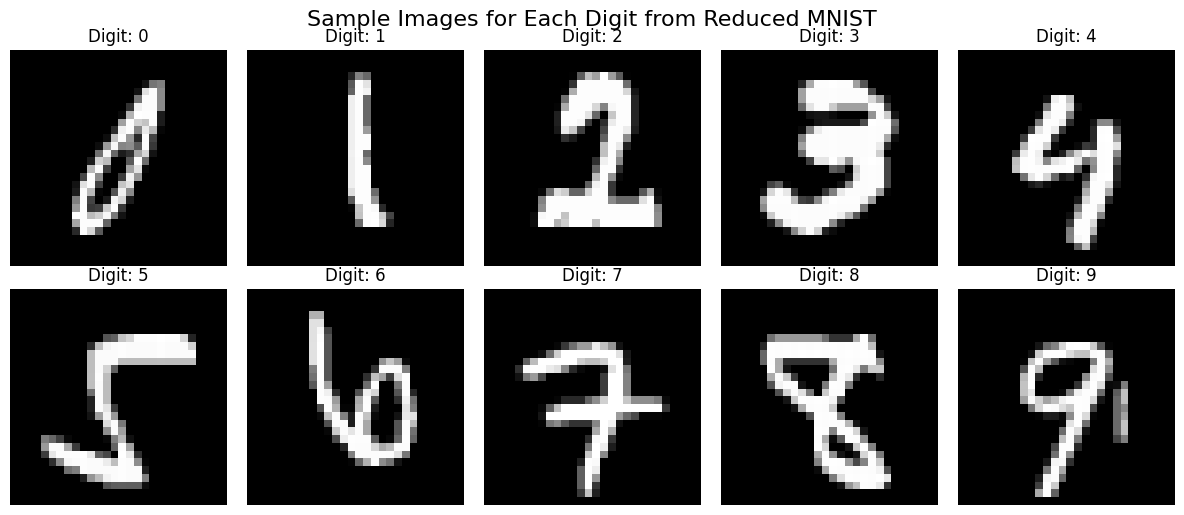

In [9]:
# Collect one sample image for each digit (0-9)
samples_per_digit = {}
for image, label in train_set:
    if label not in samples_per_digit:
        samples_per_digit[label] = image.squeeze().numpy() # Remove channel dim and convert to numpy
    if len(samples_per_digit) == 10:
        break

# Sort samples by digit for consistent display
sorted_samples = sorted(samples_per_digit.items())

# Plot the sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, (label, image_np) in enumerate(sorted_samples):
    axes[i].imshow(image_np, cmap='gray')
    axes[i].set_title(f'Digit: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Sample Images for Each Digit from Reduced MNIST', y=1.02, fontsize=16)
plt.show()

# **Question 2 - LeNet-5 Architecture & Training**
LoopObjective: Build a LeNet-5 model adjusted for $28\times28$ images.The standard LeNet expects $32\times32$. Without padding, a $5\times5$ convolution on a $28\times28$ image reduces it to $24\times24$. After pooling and a second convolution, the feature map flattens to 256. I've designed the class to accept different activations and filter counts so we can easily complete part "a" (variations).

In [10]:
class ModifiedLeNet5(nn.Module):
    def __init__(self, activation=nn.ReLU(), filter_1=6, filter_2=16, dropout=0.25, use_bn=True):
        super(ModifiedLeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, filter_1, kernel_size=5, stride=1)
        self.bn1 = nn.BatchNorm2d(filter_1) if use_bn else nn.Identity()
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(filter_1, filter_2, kernel_size=5, stride=1)
        self.bn2 = nn.BatchNorm2d(filter_2) if use_bn else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(filter_2 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.activation = activation

    def forward(self, x):
        x = self.pool(self.activation(self.bn1(self.conv1(x))))
        x = self.pool(self.activation(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(self.activation(self.fc1(x)))
        x = self.dropout(self.activation(self.fc2(x)))
        x = self.fc3(x)
        return x

def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.001, scheduler_patience=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=scheduler_patience, factor=0.5)

    print(f"Training for {epochs} epochs...")

    train_losses = []
    test_accuracies = []
    test_losses = []
    epoch_train_times_ms = []
    epoch_test_times_ms = []

    start_total_train = time.time()
    for epoch in range(epochs):
        train_start = time.time()
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_time_ms = (time.time() - train_start) * 1000
        epoch_train_times_ms.append(train_time_ms)

        test_start = time.time()
        model.eval()
        correct = 0
        total = 0
        epoch_test_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        avg_epoch_test_loss = epoch_test_loss / len(test_loader)
        test_losses.append(avg_epoch_test_loss)
        epoch_accuracy = 100 * correct / total
        test_accuracies.append(epoch_accuracy)
        test_time_ms = (time.time() - test_start) * 1000
        epoch_test_times_ms.append(test_time_ms)

        print(
            f"  Epoch {epoch+1}/{epochs}, "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Test Accuracy: {epoch_accuracy:.2f}%, "
            f"Test Loss: {avg_epoch_test_loss:.4f}, "
            f"Train Time: {train_time_ms:.1f} ms, "
            f"Test Time: {test_time_ms:.1f} ms"
        )
        scheduler.step(epoch_accuracy)

    train_time = (time.time() - start_total_train) * 1000

    start_final_test = time.time()
    model.eval()
    correct = 0
    total = 0
    final_test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            final_test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    final_test_time = (time.time() - start_final_test) * 1000
    final_accuracy = 100 * correct / total
    avg_final_test_loss = final_test_loss / len(test_loader)
    print(f"Final Test Accuracy: {final_accuracy:.2f}% | Final Test Loss: {avg_final_test_loss:.4f} | Total Test Time: {final_test_time:.1f} ms")

    if train_losses and test_losses and test_accuracies:
        last_train_time = epoch_train_times_ms[-1]
        last_test_time = epoch_test_times_ms[-1]
        last_train_loss = train_losses[-1]
        last_test_loss = test_losses[-1]
        last_accuracy = test_accuracies[-1]
        print(
            f"Summary (last epoch): "
            f"Train Loss: {last_train_loss:.4f}, "
            f"Test Loss: {last_test_loss:.4f}, "
            f"Accuracy: {last_accuracy:.2f}%, "
            f"Train Time: {last_train_time:.1f} ms, "
            f"Test Time: {last_test_time:.1f} ms"
        )

    return final_accuracy, train_time, final_test_time, train_losses, test_accuracies, test_losses

In [11]:
import matplotlib.pyplot as plt

def plot_learning_curves(experiment_results):
    num_experiments = len(experiment_results)
    if num_experiments == 0:
        print("No experiment results to plot.")
        return

    # Adjust figure size for two columns per experiment
    fig, axes = plt.subplots(num_experiments, 2, figsize=(15, 5 * num_experiments), squeeze=False)

    for i, (exp_name, results) in enumerate(experiment_results.items()):
        train_losses = results['train_losses']
        test_losses = results['test_losses']  # Get test_losses
        test_accuracies = results['test_accuracies']
        epochs = range(1, len(train_losses) + 1)

        # --- Plot 1: Training Loss and Test Loss ---
        ax_loss = axes[i, 0]
        ax_loss.plot(epochs, train_losses, label='Training Loss', marker='o', linestyle='-', color='tab:blue')
        ax_loss.plot(epochs, test_losses, label='Test Loss', marker='x', linestyle='--', color='tab:green')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.set_title(f'{exp_name} - Loss Curves')
        ax_loss.grid(True)
        ax_loss.legend(loc='best')

        # --- Plot 2: Test Accuracy ---
        ax_accuracy = axes[i, 1]
        ax_accuracy.plot(epochs, test_accuracies, label='Test Accuracy', marker='o', linestyle='-', color='tab:red')
        ax_accuracy.set_xlabel('Epoch')
        ax_accuracy.set_ylabel('Accuracy (%)')
        ax_accuracy.set_title(f'{exp_name} - Test Accuracy')
        ax_accuracy.grid(True)
        ax_accuracy.legend(loc='best')

    plt.tight_layout()
    plt.show()

# **Running Base Model & Variations (Q2.a)**

Objective: Run the base model using ReLU, then run multiple architecture/activation variations for comparison.

**Base model**: with ReLU and filters (6, 16).

**Variation 1**: Swap ReLU for Tanh (activation change).

**Variation 2**: Double filters to (12, 32) to increase model capacity.

**Variation 3**: Use LeakyReLU to reduce dead-neuron risk.

**Variation 4**: Triple filters to (18, 48) for a larger feature extractor.

**Variation 5**: `DeepLeNet` with 3 convolution layers (deeper architecture).

**Variation 6**: `LargeKernelLeNet` with a 7x7 first kernel (larger receptive field early).


--- Base Model (ReLU, Filters: 6 & 16) ---
Training for 10 epochs...
  Epoch 1/10, Train Loss: 0.7812, Test Accuracy: 94.80%, Test Loss: 0.1766, Train Time: 3215.5 ms, Test Time: 455.5 ms
  Epoch 2/10, Train Loss: 0.2014, Test Accuracy: 96.45%, Test Loss: 0.1201, Train Time: 1600.9 ms, Test Time: 219.1 ms
  Epoch 3/10, Train Loss: 0.1355, Test Accuracy: 96.90%, Test Loss: 0.1018, Train Time: 1439.0 ms, Test Time: 219.9 ms
  Epoch 4/10, Train Loss: 0.1055, Test Accuracy: 96.90%, Test Loss: 0.0932, Train Time: 1590.0 ms, Test Time: 313.5 ms
  Epoch 5/10, Train Loss: 0.0912, Test Accuracy: 97.35%, Test Loss: 0.0825, Train Time: 2021.2 ms, Test Time: 370.7 ms
  Epoch 6/10, Train Loss: 0.0756, Test Accuracy: 97.35%, Test Loss: 0.0799, Train Time: 1690.0 ms, Test Time: 224.5 ms
  Epoch 7/10, Train Loss: 0.0645, Test Accuracy: 98.20%, Test Loss: 0.0592, Train Time: 1451.3 ms, Test Time: 208.6 ms
  Epoch 8/10, Train Loss: 0.0610, Test Accuracy: 97.60%, Test Loss: 0.0816, Train Time: 1378.6 ms,

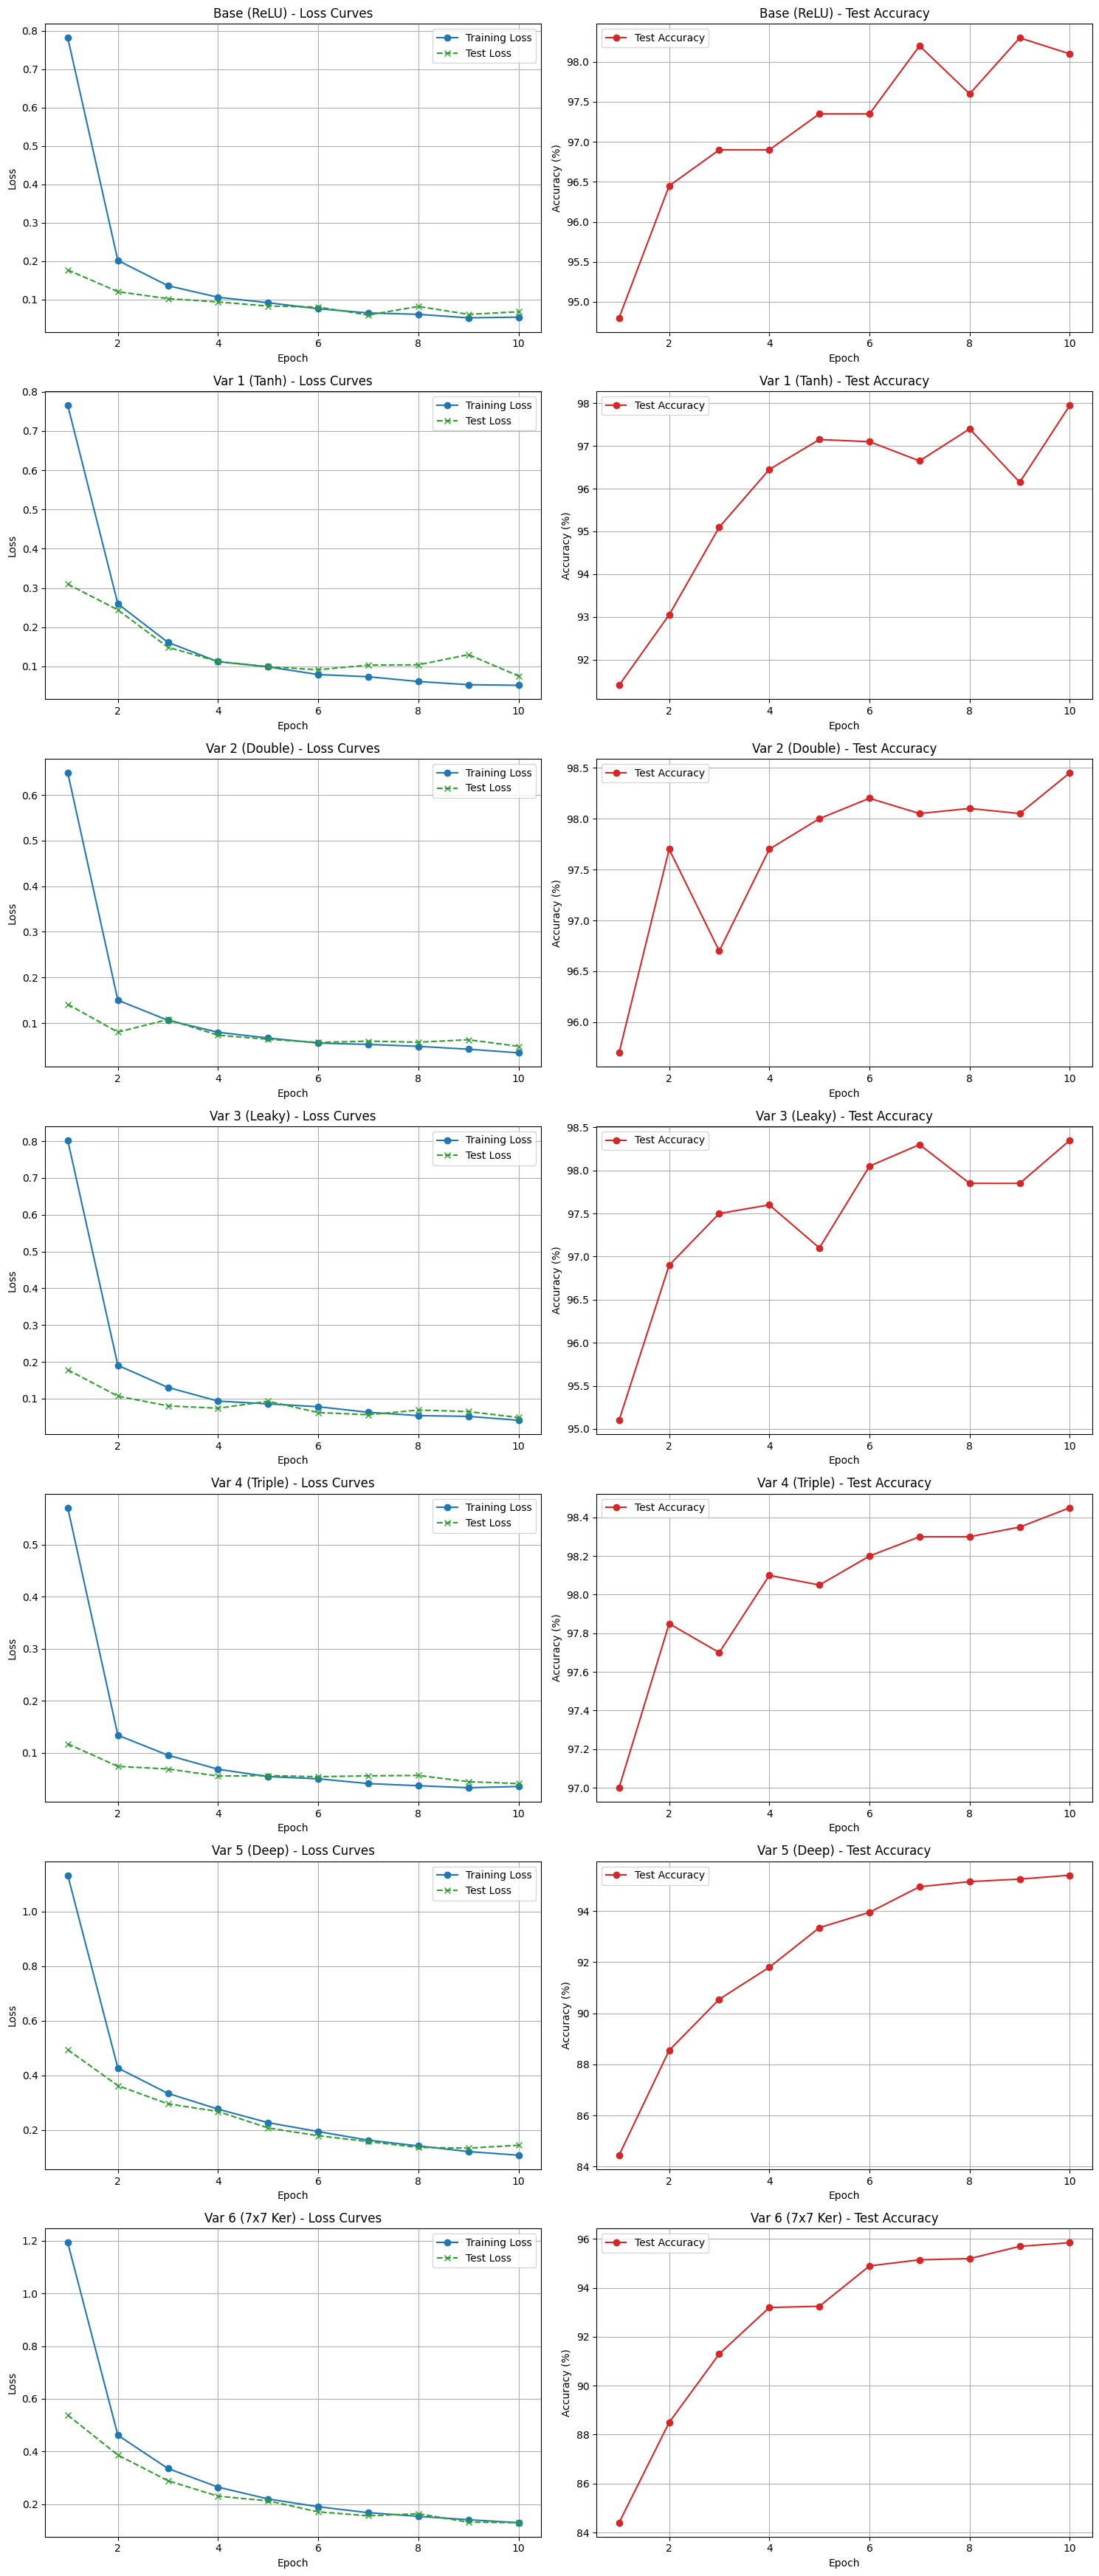

In [12]:
print("--- Base Model (ReLU, Filters: 6 & 16) ---")
base_model = ModifiedLeNet5(activation=nn.ReLU())
acc_base, train_t_base, test_t_base, train_losses_base, test_accuracies_base, test_losses_base = train_and_evaluate(base_model, train_loader, test_loader)

print("--- Variation 1: Tanh Activation ---")
var1_model = ModifiedLeNet5(activation=nn.Tanh())
acc_v1, train_t_v1, test_t_v1, train_losses_v1, test_accuracies_v1, test_losses_v1 = train_and_evaluate(var1_model, train_loader, test_loader)

print("--- Variation 2: Double Filters (12 & 32) ---")
var2_model = ModifiedLeNet5(activation=nn.ReLU(), filter_1=12, filter_2=32)
acc_v2, train_t_v2, test_t_v2, train_losses_v2, test_accuracies_v2, test_losses_v2 = train_and_evaluate(var2_model, train_loader, test_loader)

print("--- Variation 3: LeakyReLU Activation ---")
var3_model = ModifiedLeNet5(activation=nn.LeakyReLU())
acc_v3, _, _, train_losses_v3, test_accuracies_v3, test_losses_v3 = train_and_evaluate(var3_model, train_loader, test_loader)

print("--- Variation 4: Triple Filters (18 & 48) ---")
var4_model = ModifiedLeNet5(filter_1=18, filter_2=48)
acc_v4, _, _, train_losses_v4, test_accuracies_v4, test_losses_v4 = train_and_evaluate(var4_model, train_loader, test_loader)

# Fixed Variation 5: Calculated flat size for 28x28 input
class DeepLeNet(nn.Module):
    def __init__(self):
        super(DeepLeNet, self).__init__()
        self.c1 = nn.Conv2d(1, 6, 3, padding=1) # 28x28 -> pool -> 14x14
        self.c2 = nn.Conv2d(6, 16, 3, padding=1) # 14x14 -> pool -> 7x7
        self.c3 = nn.Conv2d(16, 32, 5) # 7x7 -> 3x3
        self.pool = nn.AvgPool2d(2, 2)
        self.fc = nn.Linear(32*3*3, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.c1(x)))
        x = self.pool(torch.relu(self.c2(x)))
        x = torch.relu(self.c3(x))
        return self.fc(x.view(x.size(0), -1))

print("--- Variation 5: Deep Architecture (3 Conv Layers) ---")
var5_model = DeepLeNet()
acc_v5, _, _, train_losses_v5, test_accuracies_v5, test_losses_v5 = train_and_evaluate(var5_model, train_loader, test_loader)

# Fixed Variation 6: Calculated flat size for 28x28 input
class LargeKernelLeNet(nn.Module):
    def __init__(self):
        super(LargeKernelLeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 7) # 28x28 -> 22x22 -> pool -> 11x11
        self.pool = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5) # 11x11 -> 7x7 -> pool -> 3x3
        self.fc = nn.Linear(16 * 3 * 3, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        return self.fc(x.view(x.size(0), -1))

var6_model = LargeKernelLeNet()
acc_v6, _, _, train_losses_v6, test_accuracies_v6, test_losses_v6 = train_and_evaluate(var6_model, train_loader, test_loader)

experiment_results_mnist = {
    "Base (ReLU)": {"train_losses": train_losses_base, "test_accuracies": test_accuracies_base, "test_losses": test_losses_base},
    "Var 1 (Tanh)": {"train_losses": train_losses_v1, "test_accuracies": test_accuracies_v1, "test_losses": test_losses_v1},
    "Var 2 (Double)": {"train_losses": train_losses_v2, "test_accuracies": test_accuracies_v2, "test_losses": test_losses_v2},
    "Var 3 (Leaky)": {"train_losses": train_losses_v3, "test_accuracies": test_accuracies_v3, "test_losses": test_losses_v3},
    "Var 4 (Triple)": {"train_losses": train_losses_v4, "test_accuracies": test_accuracies_v4, "test_losses": test_losses_v4},
    "Var 5 (Deep)": {"train_losses": train_losses_v5, "test_accuracies": test_accuracies_v5, "test_losses": test_losses_v5},
    "Var 6 (7x7 Ker)": {"train_losses": train_losses_v6, "test_accuracies": test_accuracies_v6, "test_losses": test_losses_v6}
}

plot_learning_curves(experiment_results_mnist)